<div style="display: flex; justify-content: space-between;">
<div style="text-align: left; display: inline-block;" align="left"><b>Tepper School of Business </b></div>
<div style="text-align: right; display: inline-block;" align="right"><i>Copyright Dennis Epple</i></div>
</div>
<hr>
<div style="display: flex; justify-content: space-between;">
<div style="text-align: left" align="left">Statistical Decision Making (45-752)</div>
</div>

# Assignment 4
The objective of this assignment is to give you experience interpreting multiple regression models. The assignment looks long, but I think you will be able to work through it relatively quickly. Also, I think you will find the results to be interesting.  

Please read: MBA Salary and GPA Analysis for Statistics Class.pdf. Then answer the following questions. In the document, note that the factor() command in the regression models accomplishes the same thing as the C() command in Colab.  

For reasons of confidentiality, I use data from several years ago. Also, for reasons of confidentiality, I cannot provide you with the data used in this assignment. Hence, I have provided you with regression results for you to interpret.

**Instructions**

Please begin your solution with a markdown cell that includes the names of your group members and your Andrew IDs.  

For each question, provide your answer in 1-2 cells following the question. Use a code cell and/or markdown cell as appropriate.

In [1]:
# This command installs tprstats from its GitHub repo. You only need to run this command once, when start the notebook.
#!pip install git+https://github.com/dnepple/tprstats-python@colab

# stress test to see if this is a good solution to problem of installing tprstats
try:
    import tprstats
except ImportError as e:
  !pip install git+https://github.com/dnepple/tprstats-python@colab
  import tprstats

In [2]:
# ====== Data Setup ======
import os, urllib.request

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

GITHUB_RAW = "https://raw.githubusercontent.com/mhnam/statistical-decision-making/main/data"

# Set working directory so that data/ is directly accessible
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
    except Exception:
        pass
    if os.path.exists("/content/drive/MyDrive/SDM/data"):
        os.chdir("/content/drive/MyDrive/SDM")
    else:
        os.makedirs("data", exist_ok=True)
else:
    for parent in [".", "..", "../.."]:
        if os.path.exists(os.path.join(parent, "data")):
            if parent != ".":
                os.chdir(parent)
            break
    else:
        os.makedirs("data", exist_ok=True)

# Download any missing data files from GitHub
def _download(filename):
    path = f"data/{filename}"
    if not os.path.exists(path):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(f"{GITHUB_RAW}/{filename}", path)

for f in ["Hospital_Satisfaction.xlsx", "Natural_Gas_Data_US.xlsx"]:
    _download(f)

print(f"Working directory: {os.getcwd()}")

HTTPError: HTTP Error 404: Not Found

**Exercise 1**  

For this exercise, we will study the Salary Regression in Table 1 of the MBA Salary and GPA Analysis document.

## Question 1a(\*)
What is the primary objective of this analysis?

## Question 1b(\*)
Please provide a one-sentence interpretation of the coefficient of TotalGPA in Table 1 in terms meaningful to an intelligent layman.

## Question 1c
What is the predicted effect on starting salary of an increase in workyears from 2 to 3 years if all other qualifications are the same? Please do the exact calculation rather than taking the derivative.

## Question 1d
Now calculate the derivative with respect to workyears and evaluate the derivative at workyears=2.5.

## Question 1e(\*)
Is the coefficient of the indicator for Female statistically significant at the 5% level in Table 1? The 10% level? Explain briefly.

## Question 1f(\*)
What is the reference year for GradYear in the regression in Table 1?  

Hint: This model is estimated using data for graduation years 2004 through 2010.

## Question 1g
Let SalaryReg be the name of the regression in Table 1. Write the command you would use to test the adequacy of the functional form of SalaryReg?

## Question 1h
The result you would obtain is as follows. What do you conclude about the adequacy of this functional form?  

- One fitted term p-value = 0.2953
- Two fitted terms p-value = 0.4367

## Question 1i
A column in the data spreadsheet has a variable named Country. This variable contains the name of the country of origin for each individual in the data set. How would we include a separate indicator variable for each country in a regression?

## Question 1j(\*)
Write the commands you would use to calculate residuals and fitted values from SalaryReg.  Name them respectively resid and yhat.

## Question 1k
Using the results from the previous item, write the plot command to plot resid on the vertical axis and yhat on the horizontal axis. Include the command to put  a horizontal red line on the graph.

## Question 1l
What word would describe the pattern we see in this plot of the residuals against workyears?

## Question 1m
Interpret the coefficient of factor(GradYear)2007. The reference year is 2004.

# Exercise 2
For this exercise, we will study the GPA Regression in Table 2.

## Question 2a(\*)
What is the objective of this analysis?


## Question 2b(\*)
Please provide a one-sentence interpretation of the coefficient of GMATVERBAL in Table 2 in terms meaningful to an intelligent layperson.

## Question 2c(\*)
Based on the magnitudes of the coefficients, it is obvious that UGPA is more important than GMATQUANT. Do you agree? Explain briefly.

## Question 2d(\*)
Is the coefficient of the indicator variable for Female statistically significant at the 5% level? The 10% level?

## Question 2e
Suppose we had used an indicator variable for male rather than female in the regression. What p-value would we obtain for the coefficient of male?

## Question 2f
 Let’s name the GPA regression GPAReg. If you had the data, how would you test the null hypothesis that the population coefficient of GMATQUANT equals the population coefficient of GMATVERBAL?

## Question 2g(\*)
The p-value for the test in part (e) is 0.5687. What do we conclude?

## Question 2h
Based on the estimates in Table 2, is there evidence of grade inflation over period studied in this regression? Please explain.

## Question 2i
If I remove GMATVERBAL from the TotalGPA equation, the coefficient of GMATWRITING increases from .008 to .021 and it is significant at the 5% level. Please provide an intuitive explanation for why this happens.

## Question 2j
What do we learn from Table 3 about the relative importance of GMATQUANT, GMATVERBAL, AND UGPA?

## Question 2k
The standardized coefficient of GMATVERBAL is .315. How do we interpret this?

## Question 2l
Suppose CountryG were made the reference country in the regression. What would be the coefficient of CountryF?

## Taking Stock
- The results are encouraging in indicating that, conditional on qualifications, men and women students perform equally well in the Tepper program, and they do equally well in starting salary.
- The results are also encouraging in suggesting that there was no grade inflation.
- The results suggest that quantitative and verbal skills are of roughly equal importance in predicting academic performance in the Tepper School.
- The above findings are of obvious managerial policy relevance to the Tepper School.


# Exercise 3
We now turn to stepwise regression and the hospital satisfaction data set.

In [2]:
import pandas
import statsmodels.api as sm

Hospital_Satisfaction = pandas.read_excel("data/Hospital_Satisfaction.xlsx")

In [3]:

def stepwise_regression(y, X, cutoff, features=[], verbose=False):
    for _ in X:
        candidates = set(X.columns) - set(features)
        candidate_pvalues = pandas.Series(index=candidates)

        for candidate in candidates:
            model = sm.OLS(y, sm.add_constant(X[features + [candidate]])).fit()
            candidate_pvalues[candidate] = model.pvalues[candidate]
        best_candidate = candidate_pvalues.idxmin()
        best_pvalue = candidate_pvalues[best_candidate]

        if best_pvalue < cutoff:
            features = features + [best_candidate]
            if verbose:
                print(
                    "Add  {:20} with p-value {:.6f}".format(best_candidate, best_pvalue)
                )
        else:
            break

    return features


## Question 3a(\*)
Estimate the following regression and report your coefficient for ROOMCLEANLINESS. Use Reg_Room.summary() to view the regression output.

In [ ]:
Reg_Room = tprstats.model(
    "cs",
    "ACCOMODATIONS~ROOMBEDDING+ROOMCLEANLINESS +ROOMDECOR+ROOMFAMILY+ROOMNOISE_IN+ ROOMNOISE_OUT+ ROOMPRIVACY+ROOMRESTROOM+ROOMSTAFFCOURTESY+ ROOMTEMPERATURE+ ROOMTV",
    Hospital_Satisfaction
)
Reg_Room.summary()

## Question 3b(\*)
Are any variables in your regression significant at the 5% level? The 10% level?


## Question 3c
The p-value at the upper right side of the regression labeled Prob(F-Statistic) is very small. What do we learn from this p-value.


## Question 3d
Now, estimate the model using stepwise regression and us p-value cutoff of 0.2.

Estimate a regression with the variables chosen by the stepwise procedure. Report your coefficient for ROOMCLEANLINESS.

In [ ]:
stepwise_regression(['ACCOMODATIONS'], [''])

## Question 3e
Re-estimate your stepwise model requiring that ROOMPRIVACY be retained in your model. Report your coefficient for ROOMPRIVACY.

## Question 3f
Suppose that the stepwise regression has selected the correct variables so that this could be interpreted as a causal model. Do you agree that the magnitudes of the coefficients in the regression tell us that ROOMRESTROOM is more important than ROOMPRIVACY or ROOMFAMILY? Hint: All three variables are on a 1 to 5 scale.

## Taking Stock
From the perspective of hospital management, the analysis of patients’ satisfaction with accommodations provides encouraging evidence that variables included in the regressions are predictive of satisfaction. A larger sample would be needed to obtain more precise estimates of the relative importance of the variables.

# Exercise 4

In this exercise, you will estimate a demand function for natural gas in the US. The data are for years 1990 through 2021, a total of 32 observations. This exercise will give you practice in investigating functional form and interpreting results when one or more variables are transformed. The variables in the data file are:  

- QG: Per capital consumption of natural gas
- PG: Price of natural gas, inflation adjusted
- PCI: Per Capita Income, inflation adjusted
- R_AMO: The range of sea surface temperatures in the Atlantic Ocean. This variable is the difference between the maximum and minimum temperatures for each year in are data.
- R_AMO_1: This is the range of Atlantic sea survace temperatures in the previous year.
- R_ENSO: The range of Equatorial sea surface temperatures each year.

It is well know that Atlantic Ocean sea surface temperatures have a profound impact on the weather throughout the United States. Equatorial sea surface temperatures are also known to impact weather in the US.  Weather in turn influences the amount of natural gas used for heating and electricity generation.

Read the data file and name it NatGasDat.

In [9]:
NatGasDat=pandas.read_excel("data/Natural_Gas_Data_US.xlsx")

## Question 4a(*)
Do you agree that the maximum of price PG was more than twice the minimum? 

Output from the describe command is provided for convenience.

In [10]:
NatGasDat.describe()

,Year,QG,PG,PCI,R_AMO,R_AMO_1,R_ENSO,R_ENSO_1
count,33.00000,32.000000,32.000000,33.000000,33.000000,33.000000,33.000000,32.000000
mean,2006.00000,81.175733,11.235828,36.563727,0.342061,0.336394,1.454545,1.521875
std,9.66954,5.378691,2.520267,6.105737,0.108896,0.096353,0.905225,0.880518
min,1990.00000,72.616345,8.136738,27.138000,0.155000,0.155000,0.200000,0.200000
25%,1998.00000,77.031606,9.633114,31.712000,0.266000,0.266000,0.700000,0.925000
50%,2006.00000,80.383620,10.402616,37.570000,0.336000,0.336000,1.300000,1.350000
75%,2014.00000,83.299939,12.570202,40.118000,0.421000,0.421000,2.000000,2.000000
max,2022.00000,94.193088,17.041968,48.490000,0.653000,0.513000,3.800000,3.800000


## Question 4b(*)
Do a plot with Year on the horizontal axis and R_AMO on the vertical axis.

In [11]:
import matplotlib.pyplot as plt
import numpy

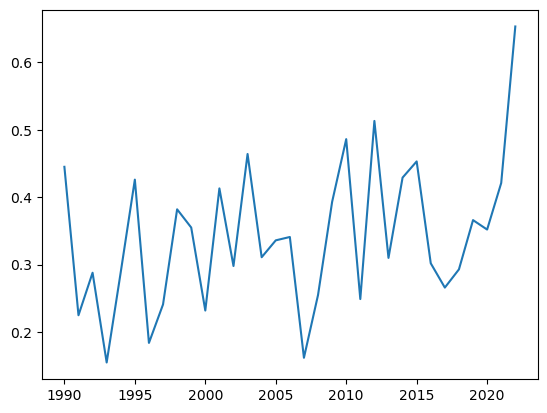

In [12]:
# Question 4b Answer
plt.plot(NatGasDat["Year"], NatGasDat["R_AMO"])

## Question 4c(*)
Estimate a regression model with QG as the dependent variable and the following as independent variables:  
PG, PCI, R_AMO, R_AMO_1,R_ENSO  

**This is a time series, so use "ts" instead of "cs" in your command.**

In [13]:
# Question 4c Answer
LinGasReg = tprstats.model("ts","QG~PG+PCI+R_AMO+R_AMO_1+R_ENSO_1",NatGasDat)
LinGasReg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     QG   R-squared:                       0.864
Model:                            OLS   Adj. R-squared:                  0.838
No. Observations:                  32   F-statistic:                     47.78
Covariance Type:                  HAC   Prob (F-statistic):           2.75e-12
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     89.0548      3.056     29.138      0.000      82.772      95.337
PG            -1.6199      0.117    -13.891      0.000      -1.860      -1.380
PCI            0.5058      0.072      7.069      0.000       0.359       0.653
R_AMO         -9.3794      3.125     -3.001      0.006     -15.803      -2.956
R_AMO_1      -10.5919      2.260     -4.687      0.000     -15.237      -5.947
R_ENSO_1      -0.9090      0.343     -2.651      0.013      -1.614      -0.204
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation robust (HAC) using 2 lags and without small sample correction
"""

## Question 4d(*)

Perform the Ramsey test on the preceding model. Based on the result of the test, does this appear to be a good functional form?

In [14]:
# Question 4d Answer
LinGasReg.ramsey_test()

,power,pvalue
0,2,0.040420
1,3,0.124023


Question 4d Answer: The relatively low p-values from the Ramsey test suggest that this is not a very good functional form.

## Question 4e
Estimate a regression model with the logarithm of QG as the dependent variable. 
As independent variables, include the logarithms of  PG and PCI. Also, include R_AMO_1 and R_ENSO not in logarithms.  
Again use "ts" instead of "cs" in your command.

## Question 4f

Are all of the coefficients in the above model significant at the 5% level?

## Question 4g

Do the coefficients of log(PG) and log(PCI) have the anticipated algebraic signs for a demand function?

## Question 4h

Give a one-sentence interpretation of the coefficient of log(PG).

## Question 4i

Suppose R_AMO increases by one unit. By what percent does predicted natural gas usage change?

## Question 4j

Test the functional form in the above regression and report your results.  

Do you agree that the above model provides a better fit to the data than the model that does not have logs of variables?  

## Question 4k

Predict natural gas demand and form a 95% prediction interval using the following values of the independent variables:  
PG= 12.57 PCI=40.12 R_AMO=0.60 R_AMO_1=0.50	R_ENSO_1=2.00